In [1]:
import matplotlib.pyplot as plt
import torch
from genkit.datasets import fetch_synthetic_data
from genkit.flow import GaussianFlowLinear
from genkit.model import LightNet
from genkit.training import train
from genkit.visitor import CoreMetricsVisitor
from genkit.plotting import PRETTY_RCPARAMS


plt.rcParams.update(PRETTY_RCPARAMS)

In [2]:
@torch.no_grad()
def mean_nn_l2(query: torch.Tensor, ref: torch.Tensor) -> float:
    d = torch.cdist(query, ref, p=2)
    return d.min(dim=1).values.mean().item()


@torch.no_grad()
def mean_loo_nn_l2(x: torch.Tensor) -> float:
    d = torch.cdist(x, x, p=2)
    d.fill_diagonal_(float("inf"))
    return d.min(dim=1).values.mean().item()


@torch.no_grad()
def copy_rate_l2(query: torch.Tensor, ref: torch.Tensor, eps: float) -> float:
    dmin = torch.cdist(query, ref, p=2).min(dim=1).values
    return (dmin <= eps).float().mean().item()

In [3]:
dim = 8
l_n_samples = [2**c for c in [9, 10, 11, 12, 13]]
n_steps = 100
batch_size = 256
n_epochs = 1024
lr = 1e-3
device = "cuda" if torch.cuda.is_available() else "cpu"
fdtype = torch.float32
idtype = torch.int32
x_train, _, x_ref = fetch_synthetic_data("unbalanced_bimodal_gaussian",
                                          n_samples=l_n_samples[-1],
                                          dim=dim,
                                          device=device,
                                          dtype=fdtype,
                                          )

In [4]:
all_trains, all_runs = [], []
for n_samples in l_n_samples:
    print("-" * 40)
    print(f"n_samples = {n_samples}")

    x_train_sub = x_train[:n_samples].clone()

    net = LightNet(dim=dim, width=64, n_blocks=4).to(device=device, dtype=fdtype)
    generator = GaussianFlowLinear(net=net, dim=dim, n_steps=n_steps, device=device, fdtype=fdtype, idtype=idtype)

    print("Training...", end="")
    generator, diagnostics = train(
        generator,
        target_data=x_train_sub,
        batch_size=batch_size,
        n_epochs=n_epochs,
        lr=lr,
        num_workers=0,
        device=device,
        visitors=[CoreMetricsVisitor()],
    )
    print("Done.")

    all_trains.append(x_train_sub)
    all_runs.append({"generator": generator, "diagnostics": diagnostics})

----------------------------------------
n_samples = 512
Training...Done.
----------------------------------------
n_samples = 1024
Training...Done.
----------------------------------------
n_samples = 2048
Training...Done.
----------------------------------------
n_samples = 4096
Training...Done.
----------------------------------------
n_samples = 8192
Training...Done.


In [5]:
gen_to_train, gen_to_test = [], []
train_to_gen, test_to_gen = [], []
train_to_train, test_to_test = [], []

for x_train_sub, run in zip(all_trains, all_runs):
    gen_model = run["generator"]

    with torch.no_grad():
        x_gen = gen_model.sample(len(x_ref))

    gen_to_train.append(mean_nn_l2(x_gen, x_train_sub))
    gen_to_test.append(mean_nn_l2(x_gen, x_ref))
    train_to_gen.append(mean_nn_l2(x_train_sub, x_gen))
    test_to_gen.append(mean_nn_l2(x_ref, x_gen))
    train_to_train.append(mean_loo_nn_l2(x_train_sub))
    test_to_test.append(mean_loo_nn_l2(x_ref))

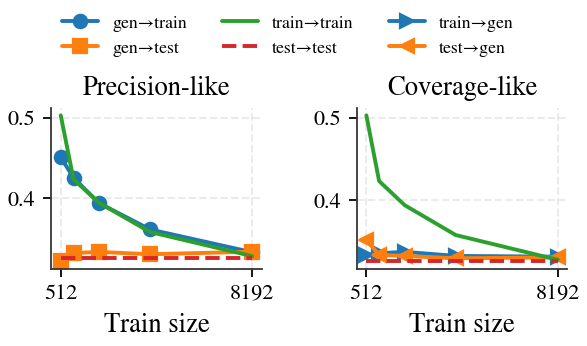

In [15]:
start = 0

fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(4, 2), squeeze=False)

axis[0, 0].plot(l_n_samples[start:], gen_to_train[start:], marker="o", label="gen→train")
axis[0, 0].plot(l_n_samples[start:], gen_to_test[start:], marker="s", label="gen→test")
axis[0, 0].plot(l_n_samples[start:], train_to_train[start:], ls="solid", label="train→train")
axis[0, 0].plot(l_n_samples[start:], test_to_test[start:], ls="dashed", label="test→test")
axis[0, 0].set_xticks([l_n_samples[start], l_n_samples[-1]])
axis[0, 0].set_xlabel("Train size")
axis[0, 0].set_title("Precision-like")

axis[0, 1].plot(l_n_samples[start:], train_to_gen[start:], marker=">", label="train→gen")
axis[0, 1].plot(l_n_samples[start:], test_to_gen[start:], marker="<", label="test→gen")
axis[0, 1].plot(l_n_samples[start:], train_to_train[start:], ls="solid", label="train→train")
axis[0, 1].plot(l_n_samples[start:], test_to_test[start:], ls="dashed", label="test→test")
axis[0, 1].set_xticks([l_n_samples[start], l_n_samples[-1]])
axis[0, 1].set_xlabel("Train size")
axis[0, 1].set_title("Coverage-like")

handles_0, labels_0 = axis[0, 0].get_legend_handles_labels()
handles_1, labels_1 = axis[0, 1].get_legend_handles_labels()
by_label = dict(zip(labels_0 + labels_1, handles_0 + handles_1))
fig.legend(by_label.values(), by_label.keys(), ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.15))

fig.tight_layout()